# BEE 4750 Homework 2: Systems Modeling and Simulation

**Name**:

**ID**:

> **Due Date**
>
> Thursday, 09/25/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to draw a systems diagram and identify the type
    of a feedback.
-   Problem 2 asks you to model contaminant concentrations in a river
    and use simulation to compare the concentrations to a regulatory
    standard.
-   Problem 3 asks you to explore the implications of an ice-albedo
    feedback in the Earth’s climate system by understanding the
    equilibria of the modeled system and their stabilities.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\nicho\OneDrive\Documents\hw02`


In [2]:
using Plots
using LaTeXStrings
using CSV
using DataFrames
using Roots

## Problems (Total: 30 Points)

### Problem 1 (5 points)

Draw a systems diagram for the relationship between global mean
temperature, atmospheric CO<sub>2</sub> concentrations, and ocean
CO<sub>2</sub> concentrations. What are the signs of the interactions
between these components and why? What does this suggest about the
overall feedback between temperature and the ocean carbon cycle?

Drawing attached separately.

> **Tip**
>
> Think about Henry’s law for CO<sub>2</sub>.

### Problem 2 (15 points)

A river which flows at 10 km/d is receiving discharges of wastewater
contaminated with CRUD from two sources which are 15 km apart, as shown
in the Figure below. CRUD decays exponentially in the river at a rate of
0.36 $\mathrm{d}^{-1}$ and is deposited by the atmosphere along the
river at a rate of 54 kg/km/d. 

<figure>
<img src="attachment:figures/river_diagram.png"
alt="Schematic of the river system in Problem 2" />
<figcaption aria-hidden="true">Schematic of the river system in Problem
2</figcaption>
</figure>

#### Problem 2.1

Draw a systems diagram with the relevant control volume(s) denoted and
any relevant in/out-flows between these boxes. How did you decide how
many boxes were needed?

Drawing attached separately

#### Problem 2.2

Develop a model for the concentration of CRUD downriver by formulating
and solving the appropriate differential equation(s) analytically.

> **Tip**
>
> Formulate your model in terms of distance downriver, rather than
> leaving it in terms of time from discharge.

#### Problem 2.3

Determine if the system in compliance with a regulatory limit of
$2.3\ \text{kg}/(1000 \text{m}^3)$. You can do this analytically or
computationally.

In [5]:
function crud(x_start, x_end, deltax)
    L = x_end - x_start #Determines the length of how far down the river we're simulating for
    n = Int(round(L / deltax)) # number of length steps
    x_vals = x_start:deltax:x_end  # array of distances
    k = 0.36 #decay rate
    U = 10 #velcoity
    A = 54 #deposition from atmosphere
    C0 = .00218 #concentration of crud in kg/cubic meters right after source 2 was fully depositited into the river
    Flow = 350000 #Total flow rate of river + source 1 + source 2
    M0 = 765.22 #Mass of crud in kg coming down from source 1

    C_vals = zeros(n + 1) #These create emtpy arrays to store values
    M_vals = zeros(n + 1)
    M_analytic = zeros(n+1)
    C_analytic = zeros(n+1)

    M_vals[1] = M0 #set the first value in the mass array equal to our starting mass of 765.22 kg

   
    for i = 1:n
        
        M_vals[i+1] = M_vals[i] + deltax * ((-k * M_vals[i] + A) / U) #this is our forward euler loop 
                                                        #equation and was found in part 2 

    end
    C_vals = (U/Flow) .* M_vals         #convert mass to concentration 

                for i in 1:(n+1)           
                    dx = x_vals[i] - x_start  #change in distance
                                                #Testing our solution analytically
                                #the following is the integrated solution that was used from part 2.
                    M_analytic[i] = M0*exp((-k*dx)/U) + (A/k)*(1 - exp((-k*dx)/U))
                    C_analytic[i] = (U/Flow) * M_analytic[i]
                    end

    return M_vals, C_vals, M_analytic, C_analytic
end



x_start = 15  #variables to use for test conditions
x_end = 600
deltax = 10

M_sim, C_sim, M_an, C_an = crud(x_start, x_end, deltax) #call the function

for i in 1:50  #print the results
    println(round(M_sim[i], sigdigits=2), " | ",
        round(C_sim[i], sigdigits=6), " | ", round(M_an[i], digits=2), " | ", round(C_an[i], sigdigits=6))
end


770.0 | 0.0218634 | 765.22 | 0.0218634
540.0 | 0.0155355 | 579.22 | 0.0165493
400.0 | 0.0114855 | 449.46 | 0.0128417
310.0 | 0.00889361 | 358.93 | 0.010255
250.0 | 0.00723477 | 295.76 | 0.00845036
220.0 | 0.00617311 | 251.7 | 0.00719129
190.0 | 0.00549365 | 220.95 | 0.00631287
180.0 | 0.00505879 | 199.5 | 0.00570001
170.0 | 0.00478048 | 184.54 | 0.00527244
160.0 | 0.00460237 | 174.09 | 0.00497413
160.0 | 0.00448837 | 166.81 | 0.004766
150.0 | 0.00441541 | 161.73 | 0.0046208
150.0 | 0.00436872 | 158.18 | 0.0045195
150.0 | 0.00433884 | 155.71 | 0.00444882
150.0 | 0.00431971 | 153.98 | 0.00439951
150.0 | 0.00430747 | 152.78 | 0.00436511
150.0 | 0.00429964 | 151.94 | 0.0043411
150.0 | 0.00429463 | 151.35 | 0.00432436
150.0 | 0.00429142 | 150.94 | 0.00431268
150.0 | 0.00428937 | 150.66 | 0.00430452
150.0 | 0.00428805 | 150.46 | 0.00429884
150.0 | 0.00428721 | 150.32 | 0.00429487
150.0 | 0.00428667 | 150.22 | 0.0042921
150.0 | 0.00428633 | 150.16 | 0.00429017
150.0 | 0.00428611 | 150.11 | 0.

The system is not in compliance as the maximum value reached in the simulation was immediately after the initial source deposit and the concentration of crud in the river was 21.9 kg per 1000 cubic meters.  This violates the regulatory limit of 2.3 kg per 1000 meters.


### Problem 3 (10 points)

In class, we discussed the ice-albedo feedback and its possible
influence on melting the hypothesized [“Snowball
Earth”](https://en.wikipedia.org/wiki/Snowball_Earth). In this problem,
we’ll introduce a simple model of the Earth’s energy balance with
includes this feedback and examine the stability of the climate.

This simple model of the energy balance (averaged over the entire
planet) is:

<span id="eq-climate">$$
\underbrace{C\frac{dT}{dt}}_{\text{change in heat}} = \underbrace{\frac{(1-\alpha)S}{4}}_{\text{incoming radiation}} - \underbrace{(A - BT)}_{\text{outgoing radiation}} + \underbrace{a\ln \left(\frac{[CO_2]}{[CO_2]_{PI}}\right)}_{\text{greenhouse effect}},
 \qquad(1)$$</span>

where:

-   $T$ is the Earth’s global mean temperature (in $^\circ\text{C}$);
-   $C$ is the heat capacity of the atmosphere and shallow ocean, taken
    to be $51\ \text{J}/\text{m}^2/^\circ\text{C}$;
-   $\alpha$ is the planetary albedo, or the fraction of incoming
    radiation reflected by the Earth, which has a present-day value of
    approximately 0.3;
-   $S$ is the solar constant, or the amount of solar radiation received
    by the Earth averaged over area, which has a present-day value of
    $1368\ \text{W}/\text{m}^2$ but during the Neoproteorozoic Era had a
    value of $1272\ \text{W}/\text{m}^2$ (this is divided by four
    because the Earth is a sphere but $S$ is the radiation captured by a
    disc with radius equal to that of the Earth);
-   $A$ and $B$ are coefficients from the linearization of outgoing
    radiation physics, and have corresponding values
    $B=-1.3\ \text{W}/\text{m}^2/^\circ\text{C}$ (estimated from a
    number of lines of evidence about the sensitivity of outgoing
    radiation to temperature; this is negative due to a sign convention
    about the direction of incoming vs. outgoing radiation) and
    $A=221.2\ \text{W}/\text{m}^2$ (estimated by assuming the
    pre-industrial temperature of $14^\circ\text{C}$ was stable without
    anthropogenic greenhouse gas emissions).

We will ignore the greenhouse effect term as we are considering the
Earth system well before humans were around.

#### Problem 3.1

Discretize the climate model
(<a href="#eq-climate" class="quarto-xref">Equation 1</a>) using forward
Euler integration and a time step of $\Delta t = 1$ yr.

In [ ]:
function Temp(t_start, deltat)
   
    dt = 1 #step time
    n = 100 #number of steps
    C = 51 #Set the constants as given above
    alpha = 0.3
    S = 1368
    A = 221.2
    B = -1.3

    T_vals = zeros(n + 1) #These create empty arrays to store values

    T_vals[1] = t_start #set the first value in the temperature array equal to our starting temperature

   
    for i = 1:n
        
        T_vals[i+1] = T_vals[i] + deltat * ((1/C)*((((1-alpha)*S)/4) - (A - B * T_vals[i]))) 
        #this is our forward euler loop equation is found from manipulating equation 1

    end
            
    return T_vals
end



t_start = 30  #variables to use for test conditions
deltat = 1

T_sim = Temp(t_start, deltat) #call the function

for i in 1:100  #print the results
    println(round(T_sim[i], sigdigits=2))
end


30.0
30.0
29.0
29.0
28.0
28.0
28.0
27.0
27.0
27.0
26.0
26.0
26.0
25.0
25.0
25.0
25.0
24.0
24.0
24.0
24.0
23.0
23.0
23.0
23.0
22.0
22.0
22.0
22.0
22.0
21.0
21.0
21.0
21.0
21.0
20.0
20.0
20.0
20.0
20.0
20.0
20.0
19.0
19.0
19.0
19.0
19.0
19.0
19.0
19.0
18.0
18.0
18.0
18.0
18.0
18.0
18.0
18.0
18.0
17.0
17.0
17.0
17.0
17.0
17.0
17.0
17.0
17.0
17.0
17.0
17.0
17.0
16.0
16.0
16.0
16.0
16.0
16.0
16.0
16.0
16.0
16.0
16.0
16.0
16.0
16.0
16.0
16.0
16.0
16.0
16.0
16.0
15.0
15.0
15.0
15.0
15.0
15.0
15.0
15.0


#### Problem 3.2

Rather than assuming a constant value for the albedo $\alpha$, we will
represent the ice-albedo feedback by letting $\alpha$ depend on $T$:

$$\alpha(T) = 
    \begin{cases} 
        \alpha_i & \quad \text{if } T \leq -10^\circ \text{C} \\
        \alpha_i + (\alpha_0 - \alpha_i)((T+10) / 20) & \quad \text{if } -10^\circ \text{C} \leq T \leq 10^\circ \text{C} \\
        \alpha_0 & \quad \text{if } T \geq 10^\circ \text{C}.
    \end{cases}$$

Let $\alpha_i = 0.5$ and $\alpha_0 = 0.3$. Simulate the simple climate
model using the Neoprotereozoic value of $S$ with temperature-varying
albedo for initial values of $T$ spanning
$-60^\circ\text{C} \leq T_0 \leq 30^\circ\text{C}$ over a period of 200
years. Plot the temperature trajectories. How many equilibria are there
and what are their stabilities?

As seen in the code below, there is only one equilibria for temperaturing-varying albedo with T varying from -60 to 30 degrees Celsius over a period of 200 years utilizing the Neoprotereozoic value of S.  The stability is at -48 degrees celsius.

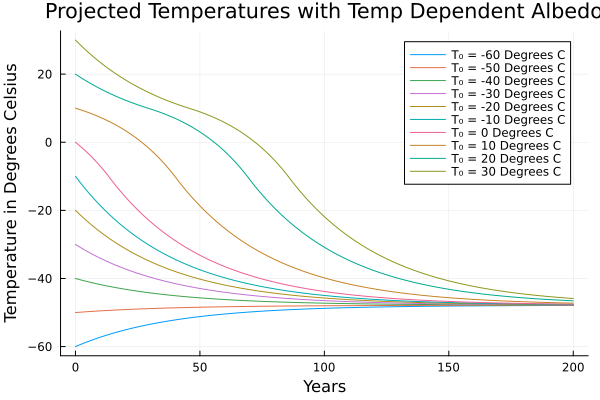

In [ ]:
function Temp(t_start, deltat)
   
    dt = 1 #step time
    n = 200 #number of steps
    C = 51 #Set the constants as given above
    S = 1272
    A = 221.2
    B = -1.3

    T_vals = zeros(n + 1) #These create empty arrays to store values

    T_vals[1] = t_start #set the first value in the temperature array equal to our starting temperature

   
    for i = 1:n #for loop to determine what albedo 
                #value to use
        
        if T_vals[i] <= -10
            alpha = 0.5
            
        elseif T_vals[i] <= 10
            alpha = 0.5 + (0.3 - 0.5)  * ((T_vals[i] + 10)/20)
            
        else 
            alpha = 0.3
            end

        T_vals[i+1] = T_vals[i] + deltat * ((1/C)*((((1-alpha)*S)/4) - (A - B * T_vals[i]))) 
        #this is our forward euler loop equation, which was found from equation 1

    end
            
    return T_vals
end



t_start_values = -60:10:30  #Set the initial temperature range
deltat = 1


plt = plot(title = "Projected Temperatures with Temp Dependent Albedo",   #Create plot
xlabel = "Years", ylabel = "Temperature in Degrees Celsius")

for T0 in t_start_values  #Call the function, and run model for
                    #each different initial temperature
    T_sim = Temp(T0, deltat)
    plot!(plt, 0:200, T_sim, label="T₀ = $(T0) Degrees C")  #Add simulated temps to plot
end


display(plt)

#### Problem 3.3

One might hypothesize that one cause for the transition from Snowball
Earth (the stable frozen equilibrium from Problem 3.2) was an increasing
amount of incoming solar radiation (as expressed by an increase in $S$).
Examine this hypothesis using our simple model. Is this factor enough to
cause the planet to warm to the pre-industrial temperature of
$14^\circ\text{C}$?

After running the model with the present-day S value (1368 W/m^2), a second equilibrium does appear at 14 degrees Celsius for initial starting temperatures of 10, 20, and 30 degrees celsius.  So, this does show that the Earth could reach the pre-industrial temperature of 14 degrees celsius, however, this factor of increasing incoming solar radiation is not enough to cause our planet to warm to the pre-industrial temperature.  In order to get to an initial temperature that yields the pre-industrial temperature result, there would need to be some sort of forcing.  I presume this is where the greenhouse effect comes into play since that has been ignored for this model.

## References

List any external references consulted, including classmates.

OpenAI. (2024). ChatGPT (Sept 25 GPT-5 version) [Large language model].
https://chat.openai.com:  I utilized ChatGPT to help specifically with understanding and implementing forward Euler, making sure units were correct, and some julia-specific syntax questions.